In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [3]:
# Step 1: Create a synthetic regression dataset
X,y = make_regression(n_samples=200, n_features=3, n_informative=3, noise=20, random_state=42)

In [4]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


In [5]:
# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42
                                                )

In [21]:
# Step 3: Multiple Linear Regression from Scratch

class MultipleLinearRegression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):
        # Add a column of 1s for the intercept term
        # X becomes:
        # [1  x1  x2  x3]
        X_train = np.insert(X_train, 0, 1, axis=1)

         # β = (XᵀX)⁻¹ Xᵀ y
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)

        # Store parameters
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self,X_test):
        # Prediction Equation
        # ŷ = Xβ + β0

        y_pred = X_test @ self.coef_ + self.intercept_
        return y_pred

In [22]:
model = MultipleLinearRegression()
model.fit(X_train,y_train)

In [23]:
print("\nIntercept (β0):")
print(model.intercept_)


Intercept (β0):
-1.2728990058172602


In [24]:
print("\nCoefficients (β1, β2, β3):")
print(model.coef_)


Coefficients (β1, β2, β3):
[71.76924392 22.15973364 72.74381876]


In [25]:
# Step 5: Make predictions
y_pred = model.predict(X_test)

In [27]:
# Step 6: Evaluate using R²
r2 = r2_score(y_test, y_pred)

print("\nR² Score:", round(r2, 4))


R² Score: 0.942


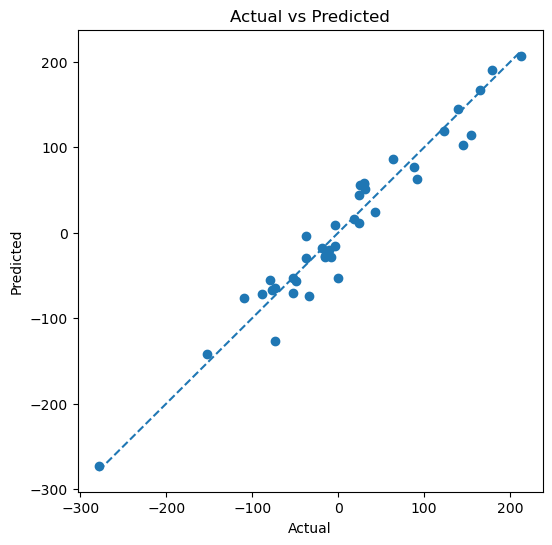

In [28]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.show()